# Ciljna promenljiva: definicija i provera

Pre bilo kakvog čišćenja podataka moramo da odlučimo **šta tačno predviđamo**. Ta odluka
određuje sve što sledi: koji redovi su upotrebljivi, šta je outlier i kako se ophodimo prema
ispitanicima koji nisu prijavili platu.

Iz opisa skupa znamo da anketa kompenzaciju beleži kroz **dve kolone** i da im se medijane razlikuju
uz skoro istu popunjenost. Koja se od njih modeluje, tamo nije odlučeno. Ovaj notebook to rešava, kroz
četiri pitanja:

1. Šta je tačno u svakoj od te dve kolone?
2. Koju biramo za ciljnu promenljivu i zašto?
3. Kako izgleda njena raspodela i da li je možemo modelovati u sirovom obliku?
4. Da li je ta kolona pouzdana, odnosno da li je izvedena onako kako tvrdimo?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))
from data_loader import load_raw, question_text

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Relative deviation a row may show from its currency median and still count
# as the same exchange rate.
THRESHOLD = 0.01

df, schema = load_raw()

print(f"redova: {len(df):,}   kolona: {len(df.columns)}")
print(f"različitih zemalja: {df['Country'].nunique()}")
print(f"različitih valuta:  {df['Currency'].nunique()}")

redova: 49,123   kolona: 170
različitih zemalja: 177
različitih valuta:  142


## 1. Šta beleže `CompTotal` i `ConvertedCompYearly`

Tekst pitanja čitamo direktno iz `survey_results_schema.csv`, da se ne oslanjamo na pretpostavke.

In [2]:
questions = question_text(schema)

for column in ["CompTotal", "ConvertedCompYearly", "Currency"]:
    text = questions.get(column, np.nan)
    print(f"--- {column} ---")
    print("nema teksta pitanja u šemi" if pd.isna(text) else text)
    print()

--- CompTotal ---
What is your current total <b>annual</b> compensation (salary, bonuses, and perks, before taxes and deductions) in terms of your day-to-day currency?  Please enter a whole number in the box below, without any punctuation.  If you are paid hourly, please estimate an equivalent yearly salary. If you prefer not to answer, please leave the box empty. 

--- ConvertedCompYearly ---
nema teksta pitanja u šemi

--- Currency ---
Which currency do you use day-to-day? If your answer is complicated, please pick the one you're most comfortable estimating in.



Iz ovoga slede dva zaključka.

**`CompTotal` je godišnji iznos**, ne mesečni: pitanje traži ukupnu godišnju kompenzaciju
(plata, bonusi i beneficije, pre poreza), u valuti koju ispitanik svakodnevno koristi, uz
uputstvo da oni plaćeni po satu procene godišnji ekvivalent. U anketi za 2025. ne postoji
kolona `CompFreq` (u ranijim godinama je postojala i beležila periodiku odgovora), pa oko
periodike nema dvosmislenosti.

**`ConvertedCompYearly` nema tekst pitanja** — vrednost u šemi je prazna. To nije previd nego
znak da ta kolona **nije anketno pitanje** nego vrednost koju je Stack Overflow izveo. Ime, uz to,
sugeriše da je izvedena iz `CompTotal`-a preračunavanjem u dolare.

Odsustvo teksta pitanja, međutim, kaže samo da kolona nije pitanje — ne i **kako** je dobijena. Da je
zaista `CompTotal` preveden u dolare je za sada pretpostavka, i proverava se u sekciji 4.

## 2. Koja kolona može biti ciljna promenljiva

Uzorak je globalan — u celom skupu ima 177 zemalja i 142 valute.
Zbog toga `CompTotal` **nije uporediv između zemalja**: iznos od 3.000.000 znači nešto sasvim
drugo u dinarima nego u evrima. Regresija nad takvom kolonom ne bi modelovala platu nego uglavnom
izbor valute.

Time otpada `CompTotal`, pa ostaje **`ConvertedCompYearly`** kao jedini kandidat. Uzimamo ga kao
**radnu odluku** — radnu zato što o toj koloni za sada znamo samo da nije anketno pitanje. Da li je
uopšte pouzdana, proverava se u sekciji 4, i tek posle te provere se odluka potvrđuje.

Alternativa bi bila da konverziju uradimo sami, iz `CompTotal`-a i kolone `Currency`. To ne radimo:
tražilo bi istorijske kurseve za sve valute na datum ankete, dakle spoljni izvor podataka, i dalo bi
istu veličinu koju Stack Overflow već nudi, samo sa dodatnom greškom koju bismo sami uveli.

Ono što ima smisla nije da konverziju ponovimo, nego da je **proverimo**.

Da se ovaj korak radi bez ijednog grafika, ima razloga. `CompTotal` i `ConvertedCompYearly` nisu dva
različita kandidata između kojih biramo po tome kako se ponašaju, nego **ista veličina u različitim
jedinicama**. To što iznosi u različitim valutama nisu međusobno uporedivi ne utvrđuje se merenjem
nego sledi iz toga šta je u koloni zapisano.

## 3. Kako izgleda ciljna promenljiva

Pre nego što proverimo pouzdanost kolone, pogledajmo njen oblik — to određuje da li je uopšte možemo
modelovati u sirovom obliku.

Ispis ispod pokazuje i koliko ispitanika uopšte ima prijavljenu kompenzaciju. Taj udeo je nizak, ali
ga ovde samo konstatujemo: pitanje ko prijavljuje platu a ko ne, i sme li se taj deo uzorka jednostavno
izbaciti, zahteva zasebnu analizu i obrađuje se u notebook-u o nedostajućim vrednostima.

In [3]:
target = df["ConvertedCompYearly"].dropna()

print(f"ispitanika sa prijavljenom kompenzacijom: {len(target):,} od {len(df):,} "
      f"({100 * len(target) / len(df):.1f}%)")
print()
print(target.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(0).to_string())
print()
print(f"odnos aritmetičke sredine i medijane:    {target.mean() / target.median():>7.2f}")
print(f"odnos maksimuma i medijane:              {target.max() / target.median():>7.0f}")
print(f"koeficijent asimetrije, sirova vrednost: {target.skew():>7.2f}")
print(f"koeficijent asimetrije, log vrednost:    {np.log(target).skew():>7.2f}")

ispitanika sa prijavljenom kompenzacijom: 23,928 od 49,123 (48.7%)

count       23928.0
mean       101792.0
std        461934.0
min             1.0
1%             65.0
25%         38171.0
50%         75384.0
75%        120630.0
99%        440856.0
max      50000000.0

odnos aritmetičke sredine i medijane:       1.35
odnos maksimuma i medijane:                  663
koeficijent asimetrije, sirova vrednost:   75.47
koeficijent asimetrije, log vrednost:      -2.58


### Grafik 1 — raspodela kompenzacije, bez ikakvih izmena

**Motivacija:** Prvo hoćemo prosto da vidimo kako izgleda raspodela ciljne promenljive u dolarima,
bez transformacija i bez podešavanja prikaza.

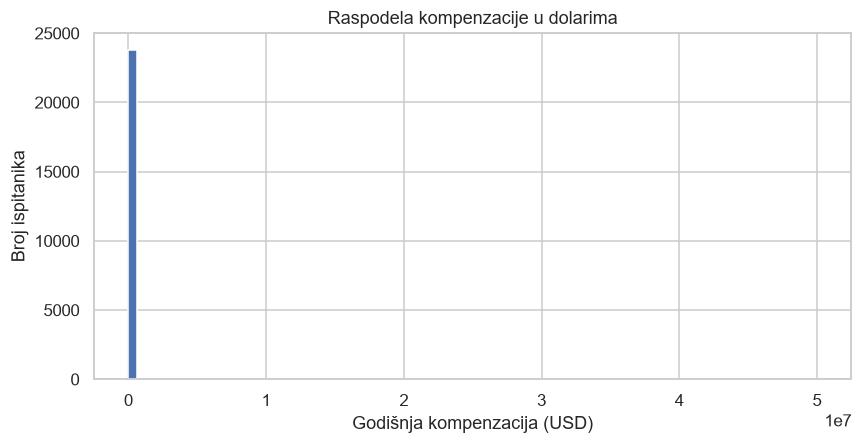

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(target, bins=80, color="#4C72B0")
ax.set_xlabel("Godišnja kompenzacija (USD)")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Raspodela kompenzacije u dolarima")
plt.tight_layout()
plt.show()

**Zapažanje:** Grafik je praktično prazan. Vidi se jedan jedini stubić uz levu ivicu, dok se X-osa
proteže sve do 50 miliona dolara. Ostali stubići postoje, ali su toliko niski da se ne razlikuju od
nule.

**Tumačenje:** Ovo nije greška u crtanju nego osobina podataka. Skoro svi ispitanici su zbijeni u
uskom pojasu na dnu skale, a nekolicina razvlači osu preko celog grafika. Iz ovakve slike ne možemo
pročitati ništa o obliku raspodele.

Prvi pokušaj da to popravimo je najblaži mogući: **ne diramo podatke, menjamo samo prikaz.**
Logaritamska Y-osa čini vidljivim i stubiće sa po nekoliko ispitanika, pored onih sa desetinama
hiljada.

### Grafik 2 — ista raspodela, sa logaritamskom Y-osom

**Motivacija:** Hoćemo da vidimo šta se nalazi izvan onog prvog stubića — dokle se raspodela zapravo
proteže i kako opada.

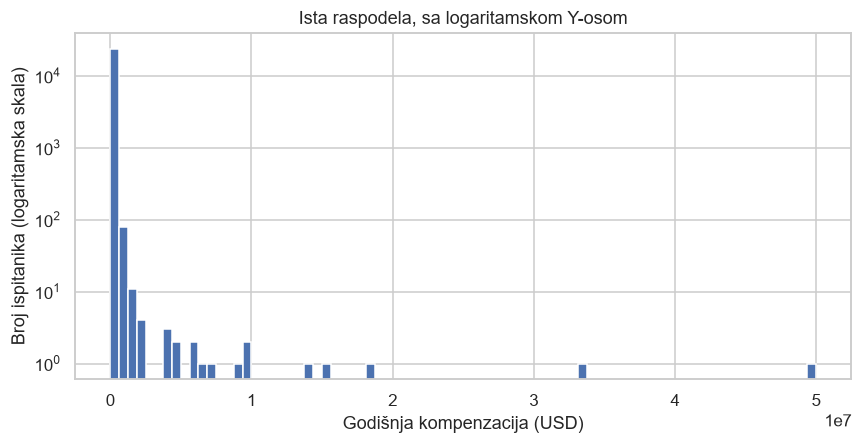

širina jednog stubića:           625,000 USD
ispitanika u prvom stubiću:       23,816 (99.5%)
stubića sa bar jednim redom:          16 od 80


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(target, bins=80, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("Godišnja kompenzacija (USD)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Ista raspodela, sa logaritamskom Y-osom")
plt.tight_layout()
plt.show()

# The same binning matplotlib used above, so we can describe the picture in numbers.
counts, edges = np.histogram(target, bins=80)
print(f"širina jednog stubića:        {edges[1] - edges[0]:>10,.0f} USD")
print(f"ispitanika u prvom stubiću:   {counts[0]:>10,} ({100 * counts[0] / len(target):.1f}%)")
print(f"stubića sa bar jednim redom:  {(counts > 0).sum():>10} od {len(counts)}")

**Zapažanje:** Sada se vidi da raspodela nije prazna nego izuzetno neravnomerna. Uz levu ivicu stoji
jedan ogroman stubić, a zatim se preko cele ose, sve do 50 miliona dolara, proteže vrlo redak rep od
svega nekoliko stubića sa po nekoliko ljudi.

Ispis ispod grafika daje tačne brojke: širina jednog stubića je **625.000 dolara**, u prvi stubić
pada **23.816 ispitanika, odnosno 99,5%** njih, a od 80 stubića samo **16** uopšte sadrži nekoga.

**Tumačenje:** Promena prikaza nam je pomogla da podatke vidimo, ali problem nije rešila — samo ga je
jasno pokazala. Rep je stvaran i vrlo dugačak, pa bi u regresiji nekoliko takvih ispitanika imalo
veću težinu od svih ostalih zajedno.

Opisna statistika iz ranije ćelije to potvrđuje: sredina je **101.792** a medijana **75.384 dolara** —
kod simetrične raspodele te dve vrednosti se poklapaju. Najveća vrednost je **663 puta veća od
medijane**, a standardna devijacija (**461.934**) preko četiri puta veća od same sredine. Isto sažeto
govori i koeficijent asimetrije od **75,47**, koji za simetričnu raspodelu iznosi nulu.

Pošto podešavanje prikaza nije dovoljno, sledeći korak je da promenimo **samu promenljivu**.

### Grafik 3 — posle logaritamske transformacije

**Motivacija:** Hoćemo da vidimo da li transformisana promenljiva ima oblik pogodan za regresiju.
Razlog da baš logaritam probamo je merna skala: razlika od 10.000 dolara znači nešto sasvim drugo kod
plate od 20.000 nego kod plate od 500.000. Logaritam relativne razlike pretvara u apsolutne, pa je
udvostručenje plate isti pomak i na dnu i na vrhu skale.

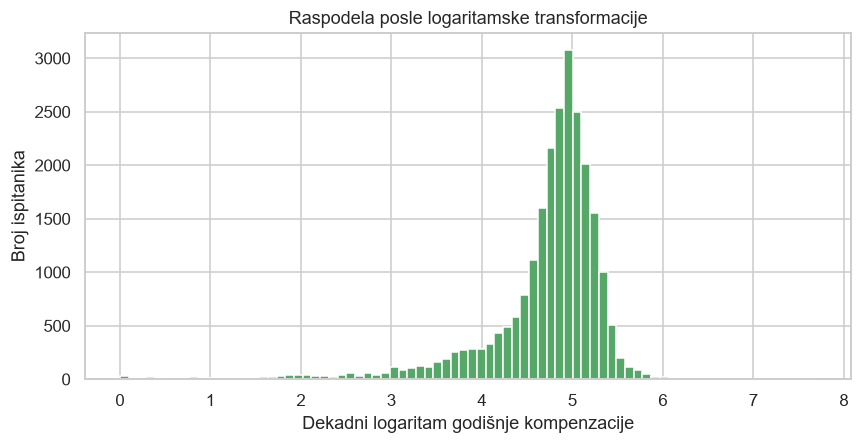

najviši stubić: log opseg 4.91–5.00, što je 80,927–101,002 USD
ispitanika u njemu: 3,081


In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(np.log10(target), bins=80, color="#55A868")
ax.set_xlabel("Dekadni logaritam godišnje kompenzacije")
ax.set_ylabel("Broj ispitanika")
ax.set_title("Raspodela posle logaritamske transformacije")
plt.tight_layout()
plt.show()

counts, edges = np.histogram(np.log10(target), bins=80)
peak = counts.argmax()
print(f"najviši stubić: log opseg {edges[peak]:.2f}–{edges[peak + 1]:.2f}, "
      f"što je {10 ** edges[peak]:,.0f}–{10 ** edges[peak + 1]:,.0f} USD")
print(f"ispitanika u njemu: {counts[peak]:,}")

**Zapažanje:** Raspodela je sada zvonasta i čitljiva na običnoj Y-osi. Ispis ispod grafika kaže da je
najviši stubić u logaritamskom opsegu **4,91–5,00**, što odgovara kompenzaciji između **80.927 i
101.002 dolara**, i da se u njemu nalazi **3.081 ispitanik**. Levo se, međutim, izdvaja izdužen rep
koji se spušta sve do nule.

**Tumačenje:** Transformacija je uspela u onome zbog čega je i probana. Desni rep je nestao,
raspodela ima upotrebljiv oblik, i ciljnu promenljivu ćemo modelovati u logaritamskom obliku.

Otkrila je, međutim, drugi problem. Koeficijent asimetrije je posle transformacije **−2,58**, dakle
rep je sada na levoj strani. Uzrok su neuverljivo male prijavljene vrednosti: prvi procenat
ispitanika prijavljuje 65 dolara godišnje ili manje, a najmanja vrednost je **1 dolar**. Logaritam
takve vrednosti ne popravlja — čini ih uočljivijim.

Zaključak sekcije: ciljnu promenljivu modelujemo u logaritamskom obliku, ali ekstremne vrednosti na
oba kraja ostaju otvoreno pitanje i rešavaju se u fazi čišćenja podataka.

Da li je transformacijom zadovoljena i pretpostavka o ujednačenom rasipanju grešaka
(homoskedastičnost) ovde ne možemo utvrditi, jer je to svojstvo grešaka modela a ne same kolone. Sa
predavanja znamo da se ona proverava Scale-Location dijagnostičkim grafikom nad rezidualima, pa to
ostavljamo za fazu modelovanja.

## 4. Hipoteza 1 — konzistentnost konverzije

> **Hipoteza:** `ConvertedCompYearly` je nastao isključivo množenjem `CompTotal`-a fiksnim kursom
> valute ispitanika. Formalno: količnik `ConvertedCompYearly / CompTotal` je konstantan unutar svake
> vrednosti kolone `Currency`.
>
> **Kriterijum, postavljen unapred:** Hipoteza je potvrđena ako u **svakoj** valuti bar **99% redova**
> odstupa manje od **1%** od medijane količnika za tu valutu. Prag nije nula zbog očekivanog
> zaokruživanja na cele dolare.

Ako se hipoteza potvrdi, dobijamo dve stvari odjednom: potvrdu da je ciljna promenljiva čista
konverzija, i dokaz da je veza između `CompTotal`-a i cilja deterministička — što ima direktnu
posledicu po izbor feature-a, o čemu na kraju notebook-a.

In [7]:
# Only rows where both columns exist and CompTotal can be divided by.
comp = df[["Currency", "Country", "CompTotal", "ConvertedCompYearly"]].dropna(
    subset=["Currency", "CompTotal", "ConvertedCompYearly"]
)
comp = comp[comp["CompTotal"] > 0].copy()

# The exchange rate each row implies.
comp["implied_rate"] = comp["ConvertedCompYearly"] / comp["CompTotal"]

median_rate = comp.groupby("Currency")["implied_rate"].transform("median")
comp["deviation"] = (comp["implied_rate"] / median_rate - 1).abs()

within = comp["deviation"] < THRESHOLD
print(f"redova sa obe vrednosti:  {len(comp):>7,}")
print(f"različitih valuta:        {comp['Currency'].nunique():>7,}")
print(f"redova u pragu od 1%:     {within.sum():>7,} ({100 * within.mean():.2f}%)")

redova sa obe vrednosti:   23,928
različitih valuta:            124
redova u pragu od 1%:      23,801 (99.47%)


In [8]:
def in_band(s):
    """Rates that sit within THRESHOLD of their own currency median."""
    return s[(s / s.median() - 1).abs() < THRESHOLD]


def rate_summary_by_currency(comp):
    """Per-currency summary of the implied exchange rate."""
    grouped = comp.groupby("Currency")["implied_rate"]
    summary = pd.DataFrame({
        "n": grouped.size(),
        "median_rate": grouped.median(),
        "pct_within": grouped.apply(lambda s: 100 * len(in_band(s)) / len(s)),
        # How many different rates the currency carries, and how far apart the
        # lowest and the highest of them are, ignoring the outlying rows.
        "distinct_in_band": grouped.apply(lambda s: in_band(s).nunique()),
        "spread_in_band_pct": grouped.apply(
            lambda s: 100 * (in_band(s).max() / in_band(s).min() - 1)
        ),
    })
    return summary.sort_values("n", ascending=False)


summary = rate_summary_by_currency(comp)
summary.head(12).round(4)

,n,median_rate,pct_within,distinct_in_band,spread_in_band_pct
Currency,,,,,
EUR European Euro,6884,1.1601,99.7966,556,1.4493
USD United States dollar,6315,1.0000,100.0000,1,0.0000
GBP Pound sterling,1495,1.3614,99.7324,208,1.2270
INR Indian rupee,1067,0.0116,99.1565,158,0.5747
CAD Canadian dollar,905,0.7296,99.8895,157,1.0204
BRL Brazilian real,592,0.1820,99.1554,156,0.8018
AUD\tAustralian dollar,564,0.6501,99.8227,121,0.0171
PLN Polish zloty,538,0.2729,99.4424,132,0.1955
SEK\tSwedish krona,459,0.1048,99.7821,138,0.1908


Prvi red tabele već pokazuje da nešto ne stoji: kod evra postoji **više stotina različitih
kurseva**, a ne jedan. Kod dolara je, očekivano, kurs tačno 1 i jedinstven — to je usput i dobra
kontrola da račun radi ispravno.

Pitanje je onda kolika su ta odstupanja i kako izgledaju.

### Grafik 4 — sva odstupanja, ceo opseg

**Motivacija:** Hoćemo da vidimo koliko su velika odstupanja implicitnog kursa od medijane za
sopstvenu valutu i dokle se uopšte protežu. Y-osu odmah postavljamo na logaritamsku, pošto smo u
prethodnoj sekciji videli šta se dešava kad se to ne uradi kod raspodele sa dugačkim repom.

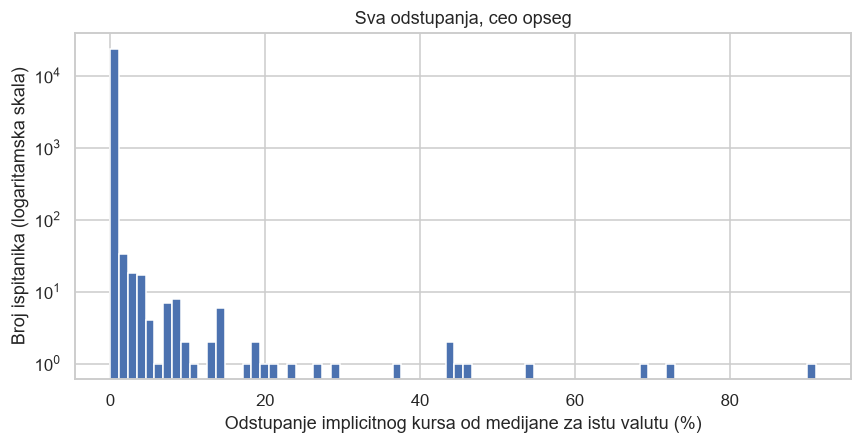

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))

ax.hist(comp["deviation"] * 100, bins=80, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("Odstupanje implicitnog kursa od medijane za istu valutu (%)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Sva odstupanja, ceo opseg")
plt.tight_layout()
plt.show()

**Zapažanje:** Gotovo svi ispitanici su u prvom stubiću, uz nulu. Ostatak je vrlo redak, a osa se
završava na oko 91% — dalje od toga nema nijednog ispitanika.

**Tumačenje:** Iz toga dokle se osa proteže sledi jedan zaključak koji vredi izvući. U ranijim
godinama ankete postojala je kolona `CompFreq`, koja je beležila periodiku prijavljenog iznosa, pa je
Stack Overflow deo odgovora sam svodio na godišnji nivo.

Da je isto radio i ovde, videlo bi se, i vredi proći kroz jedan primer. Neka je ispitanik u
`CompTotal` upisao **5.000 evra**, a to je zapravo mesečni iznos. Ako bi Stack Overflow taj iznos
sveo na godišnji pre konverzije, u `ConvertedCompYearly` bi otišlo `5.000 × 12 × kurs`, dok bi u
`CompTotal` ostalo 5.000. Količnik te dve kolone, koji mi računamo kao implicitni kurs, bio bi onda
**dvanaest puta veći** od kursa za evro. Prema medijani za tu valutu to je količnik 12, pa odstupanje
`|12 − 1| = 11`, odnosno **1.100%**.

Grafik se završava na oko 91%, dakle tako velikih odstupanja nema.

Sa slike se, međutim, vidi samo dokle osa seže, a ne i da baš u okolini vrednosti 12 nema nikoga.
Zato to proveravamo računom.

In [10]:
# A monthly amount annualised would be twelve times its currency median.
MONTHLY_FACTOR = 12

# How far each row's rate sits from its currency median, as a plain ratio.
rate_ratio = comp["implied_rate"] / median_rate

print(f"odstupanje koje bi red sveden sa mesečnog nosio: "
      f"{100 * (MONTHLY_FACTOR - 1):.0f}%")
print(f"redova u okolini faktora {MONTHLY_FACTOR}:        "
      f"{rate_ratio.between(0.9 * MONTHLY_FACTOR, 1.1 * MONTHLY_FACTOR).sum():>8}")
print()
print(f"najmanji zabeleženi količnik prema medijani: {rate_ratio.min():>8.3f}")
print(f"najveći zabeleženi količnik prema medijani:  {rate_ratio.max():>8.3f}")
print(f"najveće odstupanje u celom skupu:           {100 * comp['deviation'].max():>7.1f}%")

odstupanje koje bi red sveden sa mesečnog nosio: 1100%
redova u okolini faktora 12:               0

najmanji zabeleženi količnik prema medijani:    0.705
najveći zabeleženi količnik prema medijani:     1.912
najveće odstupanje u celom skupu:              91.2%


**Nalaz:** U okolini faktora dvanaest nema nijednog reda, a najveći zabeleženi količnik prema medijani
je 1,91. **Stack Overflow, dakle, nije primenio nikakvu transformaciju osim konverzije valute.**

Vredi naglasiti šta ovo *ne* znači. Provera ne može da otkrije ispitanika koji je **sam** pogrešio i
uneo mesečnu platu umesto godišnje.

Razlika je u tome ko greši. U primeru iznad iznos je menjao Stack Overflow, pa je promena ulazila
samo u **jednu** od dve kolone i količnik se pomerao. Kad grešku napravi ispitanik, on u `CompTotal`
upiše 5.000 umesto 60.000, a `ConvertedCompYearly` se **iz tog istog broja** izračuna kao
`5.000 × kurs`. Količnik je onda `5.000 × kurs / 5.000`, dakle običan kurs za tu valutu — isti kao
kod svih ispravnih redova. Greška se u količniku skrati i red izgleda potpuno uredno.

Ovde, dakle, tražimo transformaciju koju je uveo Stack Overflow, ne grešku ispitanika — ta druga je
zaseban problem i rešava se u fazi čišćenja outliera.

### Grafik 5 — uvećan prikaz malih odstupanja

**Motivacija:** Ostaje da vidimo kako izgledaju ona odstupanja koja jesu tu, u pojasu od nekoliko
procenata oko nule. Na prethodnom grafiku se taj pojas svodio na jedan stubić, pa sve preko 3%
sabijamo u poslednji stubić da bismo ga videli izbliza.

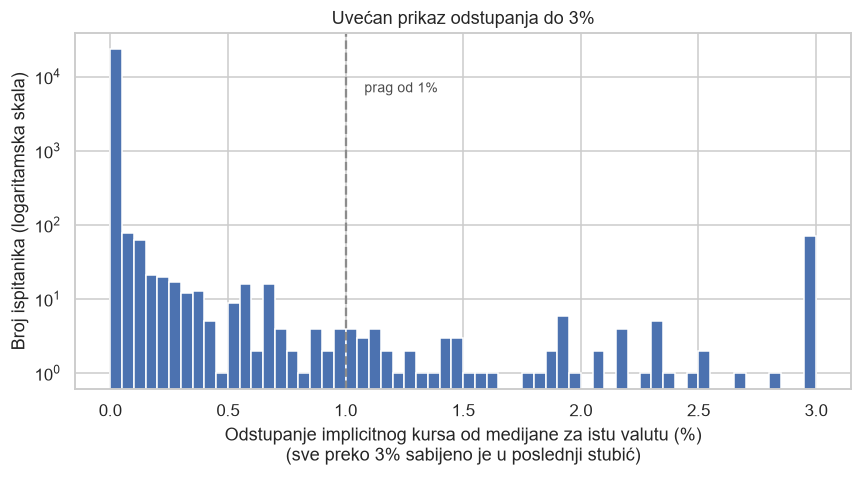

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Deviations above 3% go into the last bin, so the bulk of the data stays legible.
ax.hist(np.clip(comp["deviation"] * 100, 0, 3), bins=60, color="#4C72B0")
ax.axvline(THRESHOLD * 100, color="#8C8C8C", linestyle="--", linewidth=1.5)
ax.text(1.08, ax.get_ylim()[1] * 0.25, "prag od 1%", color="#4C4C4C", fontsize=9)

ax.set_yscale("log")
ax.set_xlabel("Odstupanje implicitnog kursa od medijane za istu valutu (%)\n"
              "(sve preko 3% sabijeno je u poslednji stubić)")
ax.set_ylabel("Broj ispitanika (logaritamska skala)")
ax.set_title("Uvećan prikaz odstupanja do 3%")
plt.tight_layout()
plt.show()

**Zapažanje:** Odstupanja opadaju glatko i neprekidno, bez ijedne izdvojene grupe. Prag od 1%, koji
smo postavili unapred, seče taj niz na proizvoljnom mestu — na samoj toj vrednosti se u podacima ne
dešava ništa posebno.

**Tumačenje:** Takav oblik odgovara veličini koja se menja neprekidno, dakle kursu koji se pomerao
tokom trajanja ankete. Da je posredi bila neka sistematska intervencija nad delom podataka,
očekivali bismo zgusnuće na određenoj vrednosti, a ne ravnomerno proređivanje.

### Grafik 6 — da li kriterijum prolazi u svakoj valuti

**Motivacija:** Kriterijum smo postavili po valuti, a ne na celom skupu, pa ga tako treba i
proveriti — ukupan procenat od 99,47% bi sakrio valute sa malo ispitanika. Gledamo dvadeset valuta
sa najviše ispitanika.

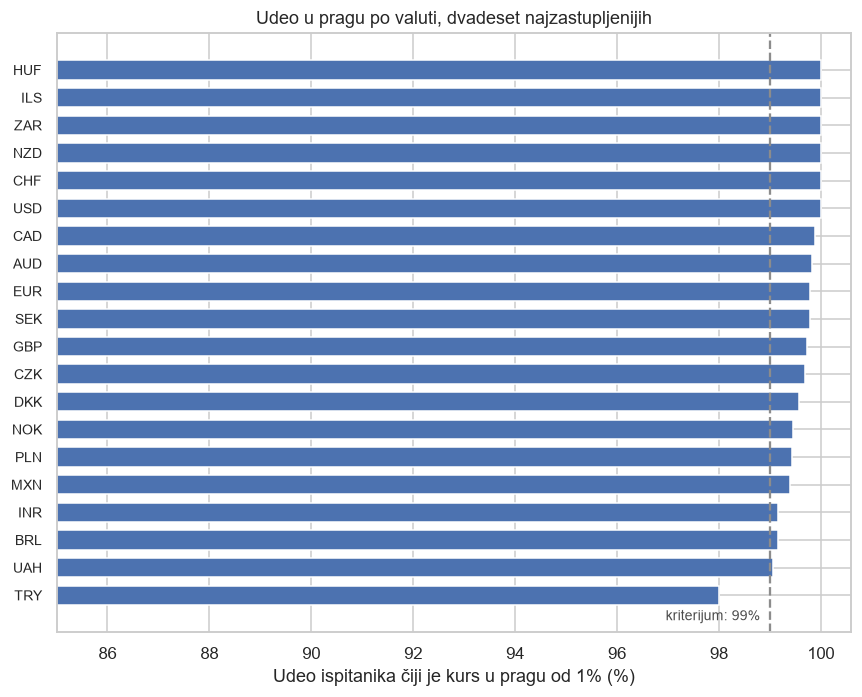

In [12]:
top20 = summary.head(20).sort_values("pct_within")

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(range(len(top20)), top20["pct_within"], color="#4C72B0", height=0.7)
ax.axvline(99, color="#8C8C8C", linestyle="--", linewidth=1.5)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels([v.split()[0] for v in top20.index], fontsize=9)
ax.set_xlim(85, 100.6)
ax.set_xlabel("Udeo ispitanika čiji je kurs u pragu od 1% (%)")
ax.set_ylabel("")
ax.set_title("Udeo u pragu po valuti, dvadeset najzastupljenijih")
ax.text(98.8, -0.9, "kriterijum: 99%", color="#4C4C4C", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

In [13]:
failing = summary[summary["pct_within"] < 99]

print(f"valuta koje ne zadovoljavaju kriterijum: {len(failing)} od {len(summary)}")
print(f"ispitanika u njima: {int(failing['n'].sum()):,} od {len(comp):,}")
print()
print(failing.sort_values("n", ascending=False).head(15)[["n", "pct_within"]].round(2).to_string())

valuta koje ne zadovoljavaju kriterijum: 24 od 124
ispitanika u njima: 1,368 od 23,928

                              n  pct_within
Currency                                   
TRY\tTurkish lira           150       98.00
BGN\tBulgarian lev          133       98.50
JPY\tJapanese yen           123       96.75
CNY\tChinese Yuan Renminbi  111       91.89
COP\tColombian peso         102       83.33
ARS\tArgentine peso          90       95.56
NGN\tNigerian naira          85       89.41
IDR\tIndonesian rupiah       79       96.20
PHP\tPhilippine peso         74       98.65
KES\tKenyan shilling         64       96.88
TWD New Taiwan dollar        63       92.06
RSD\tSerbian dinar           55       98.18
VND\tVietnamese dong         52       92.31
THB\tThai baht               45       97.78
KRW\tSouth Korean won        37       94.59


**Zapažanje:** Kod većine prikazanih valuta udeo je preko 99%, kod dolara tačno 100%, a kod jednog
dela valuta pada ispod praga. Ispis iznad pokazuje da je takvih **24 od 124 valute**, i da one
zajedno nose svega **1.368 od 23.928 ispitanika**.

**Tumačenje:** Te valute nisu nasumičan skup. Najvećim delom su to valute tržišta u razvoju, čiji je
kurs tokom perioda ankete izraženije oscilovao — kolumbijski pezo, nigerijska naira, argentinski
pezo, turska lira, vijetnamski dong. Među njima ima i stabilnijih valuta, poput japanskog jena i
bugarskog leva, gde je odstupanje manje ali i dalje iznad praga. Obrazac, dakle, prati kretanje
kursa, a ne grešku u podacima.

## 5. Nalaz i verdikt

**Verdikt: hipoteza je opovrgnuta** — ali na način koji je koristan, pa vredi precizno reći šta je
oboreno, a šta nije.

Oboren je deo o **konstantnosti**: kurs nije jedna vrednost po valuti. To se vidi u koloni
`distinct_in_band` — kod evra 556 različitih kurseva, kod funte 208, kod kanadskog dolara 157.
Kolona `spread_in_band_pct` govori koliko su najniži i najviši od njih udaljeni: 1,45% kod evra,
1,23% kod funte. Jedini izuzetak je dolar, sa tačno jednim kursom i rasponom nula — što je očekivano,
pošto je ciljna promenljiva izražena baš u dolarima.

Taj raspon je po načinu računanja ograničen na oko 2%, jer se računa samo nad redovima unutar praga.
Kod valuta koje su tokom ankete jače oscilovale višak kretanja se zato ne vidi kao širi raspon, nego
tako što redovi **ispadaju iz praga** — a to je upravo ono što meri Grafik 6.

Nije oboren deo o **determinisanosti**: u svakom pojedinačnom redu veza
`ConvertedCompYearly = CompTotal * kurs` važi tačno. Menja se samo kurs između redova.

Najuverljivije objašnjenje je da je konverzija rađena po kursu na dan odgovora, a ne jednim kursom za
celu anketu. To se slaže sa svime što vidimo: neprekidna raspodela odstupanja, raspon reda veličine
procenta kod stabilnih valuta i mnogo veći raspon kod valuta koje su tokom perioda ankete stvarno
oscilovale. **Ovo objašnjenje, međutim, ne možemo da dokažemo** — dataset ne sadrži nijednu kolonu sa
datumom odgovora, pa nemamo čime da povežemo kurs sa vremenom. Ostaje kao najverovatnije tumačenje,
ne kao utvrđena činjenica.

Uz ovu proveru namerno ne ide statistički test. Tvrdnja koju ispitujemo je deterministička — da li
jedna kolona nastaje množenjem druge — a ne tvrdnja o slučajnoj promenljivoj. Test značajnosti ovde
ne bi imao šta da testira; odgovor daju udeli i krajnje vrednosti. Statistički testovi dolaze u
narednim fazama, gde se porede grupe ispitanika.

**Posledica po dalji rad:** `ConvertedCompYearly` prihvatamo kao ciljnu promenljivu. Konverzija je
dosledna, bez tragova sistematske greške, a varijacija od oko procenta je zanemarljiva u odnosu na
raspon plata koji modelujemo (od hiljada do stotina hiljada dolara).

Ono što ova provera **ne** može da utvrdi jeste da li su ispitanici tačno odgovorili. Pošto Stack
Overflow `ConvertedCompYearly` računa iz `CompTotal`-a, svaka greška ispitanika ulazi u obe kolone i
količnik ostaje netaknut. Ispitanik koji je uneo mesečnu platu ovde je nevidljiv. To je zasebno
pitanje i traži drugu metodu — poređenje sa tipičnom platom za istu zemlju — i biće obrađeno u fazi
čišćenja outliera.

## 6. Posledica po izbor feature-a: `CompTotal` se isključuje

Provera je usput dokazala nešto važnije od same pouzdanosti kolone.

Pošto u svakom redu važi `ConvertedCompYearly = CompTotal * kurs(Currency)`, `CompTotal` **nije
prediktor plate — on jeste plata**, samo zapisana u drugoj valuti. Model koji bi na ulazu dobio
`CompTotal` i `Currency` mogao bi da rekonstruiše ciljnu promenljivu skoro savršeno, jednostavno tako
što bi naučio kurseve. Dobili bismo model sa gotovo idealnim rezultatom koji o platama nije naučio
ništa, jer bi koeficijenti uz iskustvo, obrazovanje i sve ostalo pali na nulu — uz `CompTotal` ništa
drugo ne doprinosi.

To je **curenje podataka** (engl. *data leakage*): situacija u kojoj model na ulazu dobije informaciju
izvedenu iz onoga što treba da predvidi. Rezultat izgleda odlično, a model je bezvredan, jer pitanje
na koje treba da odgovori — šta određuje visinu kompenzacije — ostaje neodgovoreno.

**Odluka: `CompTotal` ne ulazi u skup feature-a.** Veza je simetrična, pa bi isto važilo i obrnuto:
da smo za cilj uzeli `CompTotal`, `ConvertedCompYearly` bi bio curenje. Ne smemo koristiti obe strane
iste jednačine.

`Currency` i `Country` ostaju legitimni feature-i — oni nose informaciju o tržištu rada i kupovnoj
moći, a ne o samoj vrednosti plate koju predviđamo.